In [45]:
# ===============================================
# 1. Import Libraries
# ===============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [46]:
# ===============================================
# 2. Load Dataset
# ===============================================
df = pd.read_csv("../dataset/cleaned_dataset.csv")
print("Shape:", df.shape)

Shape: (21588, 27)


#### UNIVARIATE ANALYSIS

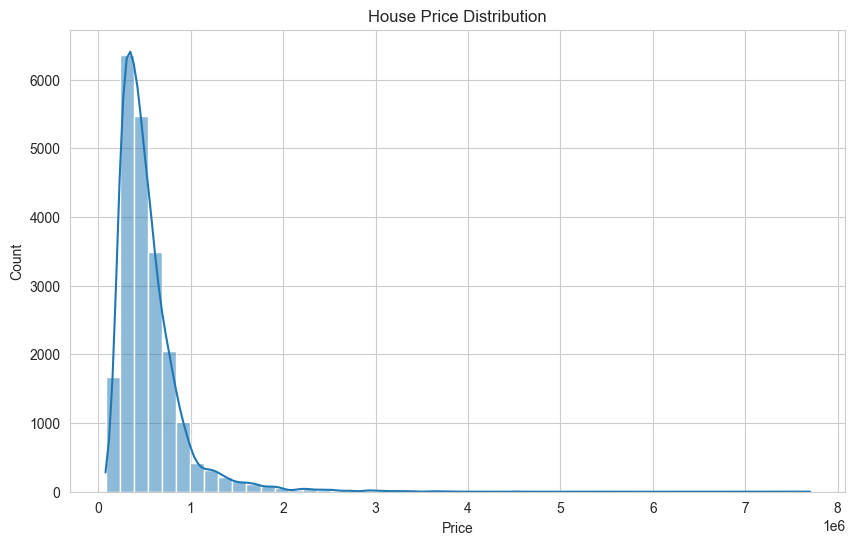

In [25]:
# ===============================================
# 3 Target Distribution
# ===============================================

plt.figure(figsize=(10,6))
sns.histplot(df["price"], bins=50, kde=True)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

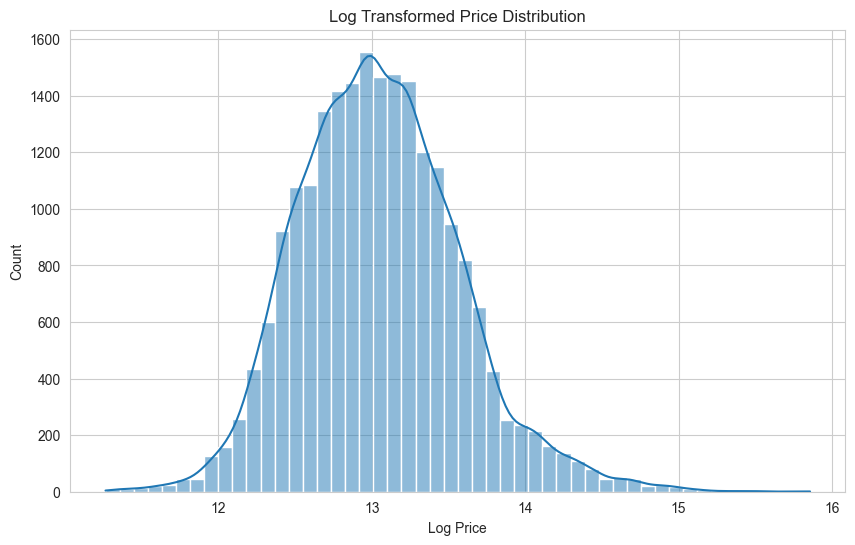

In [26]:
# ===============================================
# 4 Log Transformed Price
# ===============================================

plt.figure(figsize=(10,6))
sns.histplot(df["price_log"], bins=50, kde=True)
plt.title("Log Transformed Price Distribution")
plt.xlabel("Log Price")
plt.ylabel("Count")
plt.show()

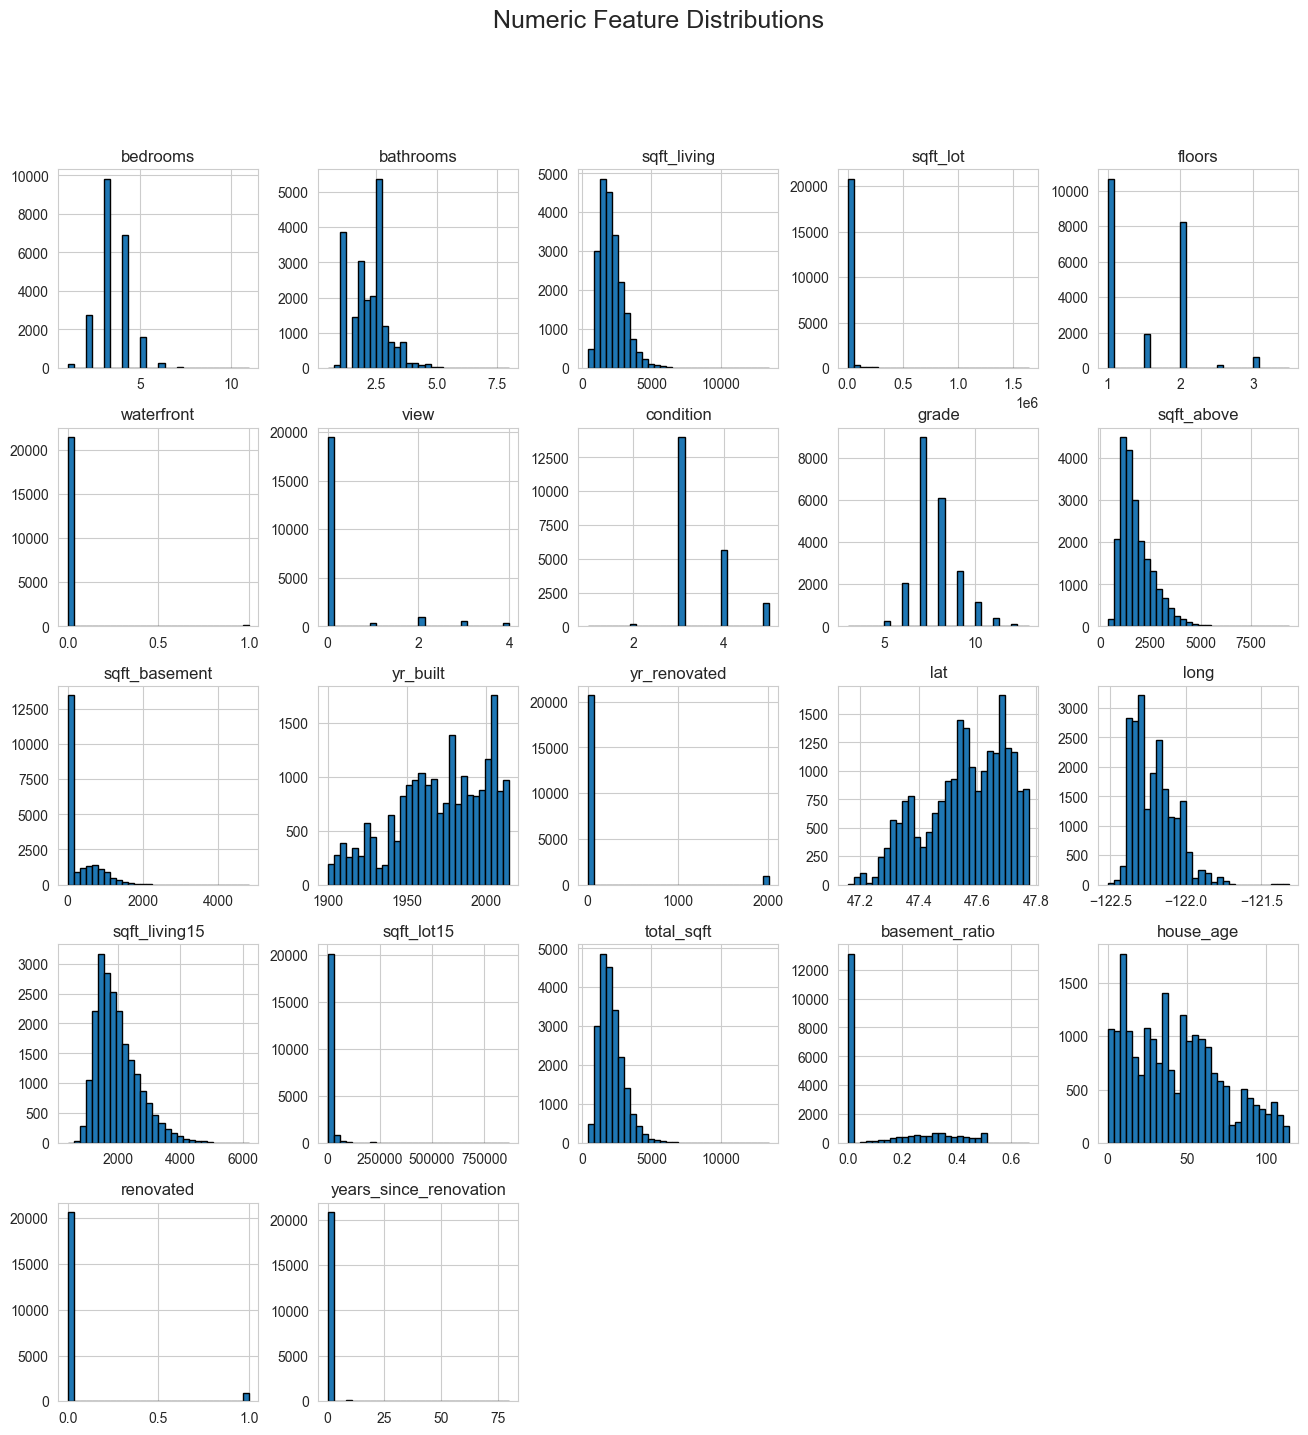

In [27]:
# ===============================================
# 5 Histogram for Numeric features
# ===============================================

numeric_cols = df.select_dtypes(include=np.number).columns
exclude_cols = ["price","price_log","zipcode","sale_year","sale_month"]        # EDA should separate original features from engineered ones also.
hist_cols = [col for col in numeric_cols if col not in exclude_cols]
df[hist_cols].hist(figsize=(16,16), bins=30, edgecolor="black")
plt.suptitle("Numeric Feature Distributions", fontsize=18)
plt.show()

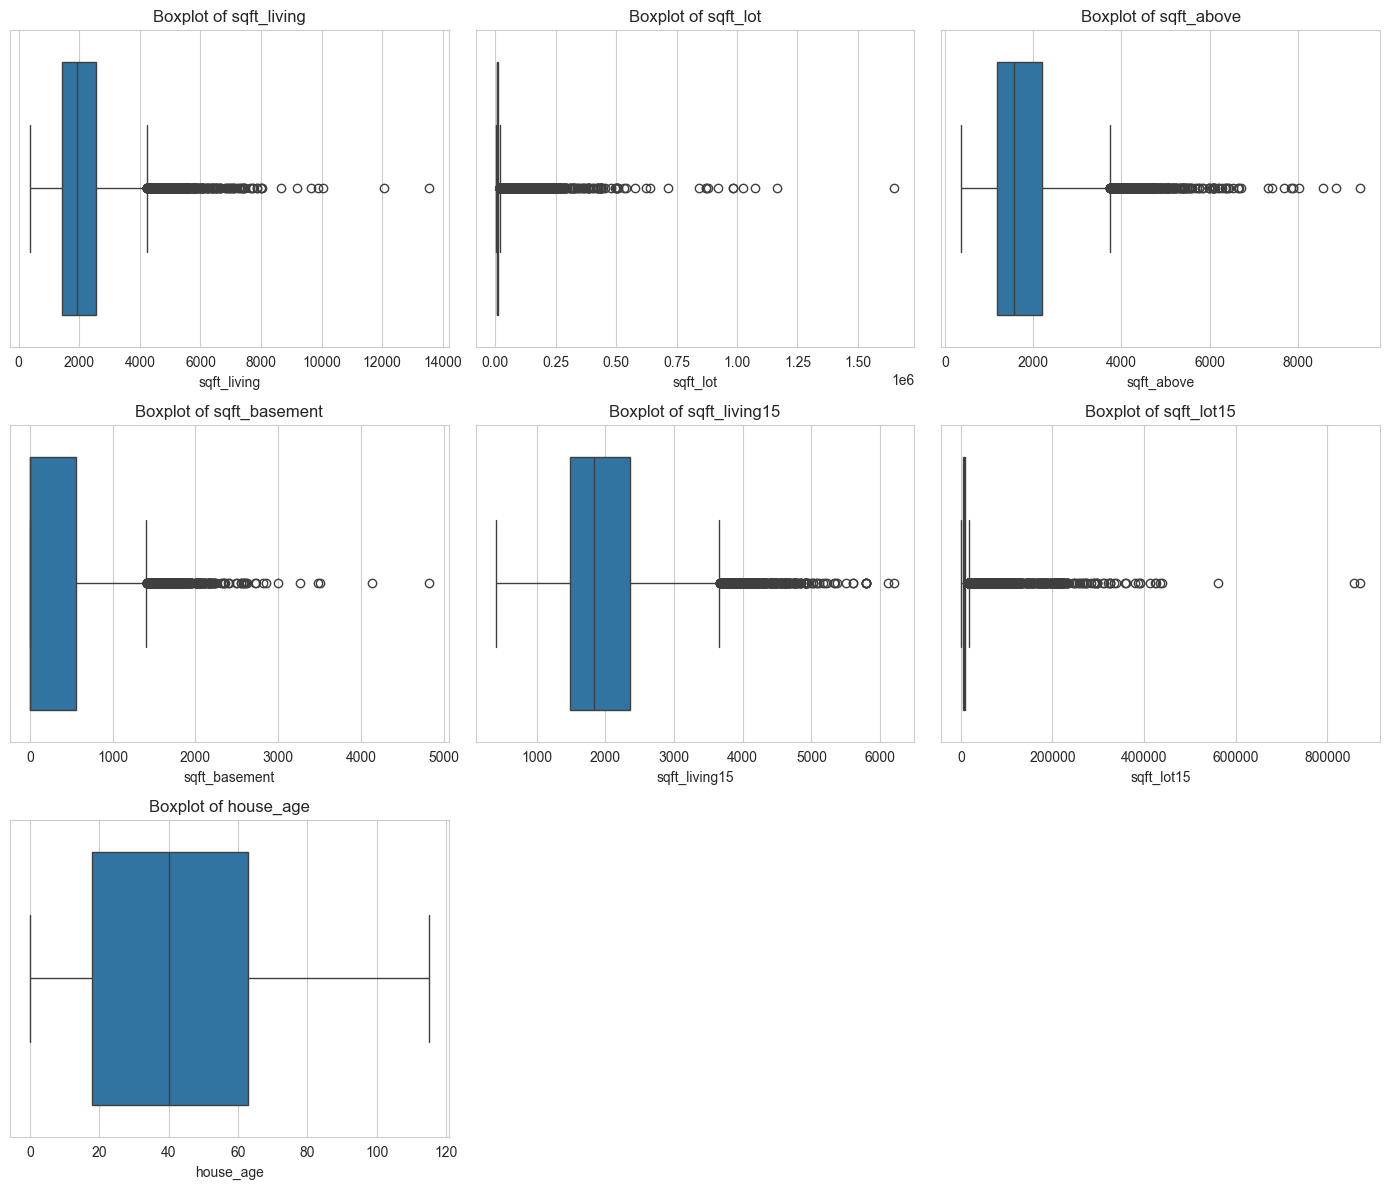

In [28]:
# ===============================================
# 6 Boxplot for Important Numeric Features
# ===============================================

important_numeric = [
"sqft_living",
"sqft_lot",
"sqft_above",
"sqft_basement",
"sqft_living15",
"sqft_lot15",
"house_age"
]

plt.figure(figsize=(14,12))
for i,col in enumerate(important_numeric,1):
    plt.subplot(3,3,i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()

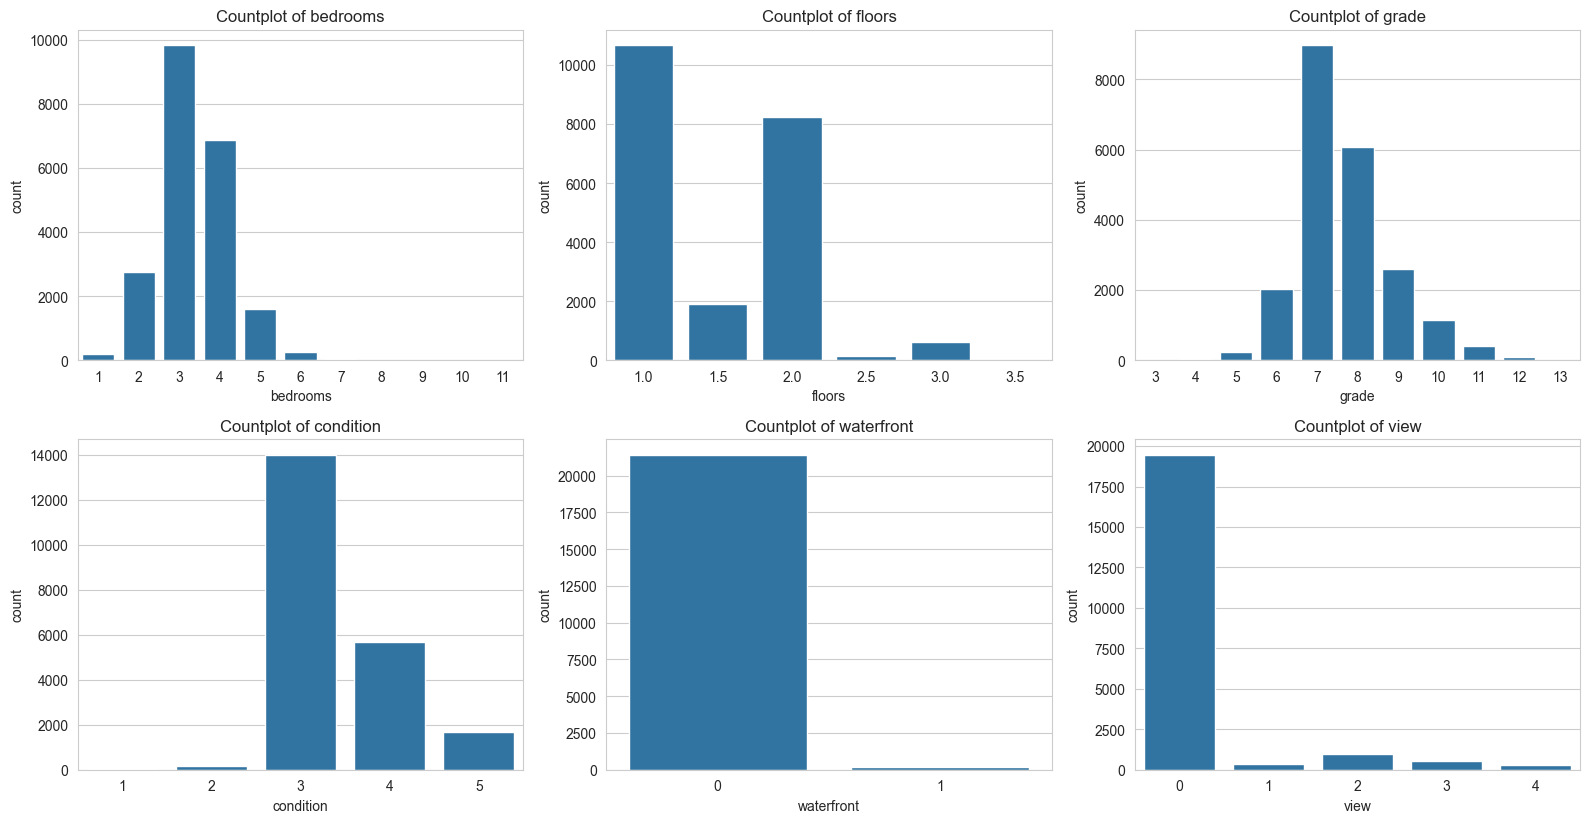

In [29]:
# ===============================================
# 7 Categorical Feature Analysis
# ===============================================

categorical_cols = [
'bedrooms',
'floors',
'grade',
'condition',
'waterfront',
'view'
]

plt.figure(figsize=(16,12))
for i,col in enumerate(categorical_cols,1):
    plt.subplot(3,3,i)
    sns.countplot(x=df[col])
    plt.title(f"Countplot of {col}")
plt.tight_layout()
plt.show()

#### BIVARIANT ANALYSIS

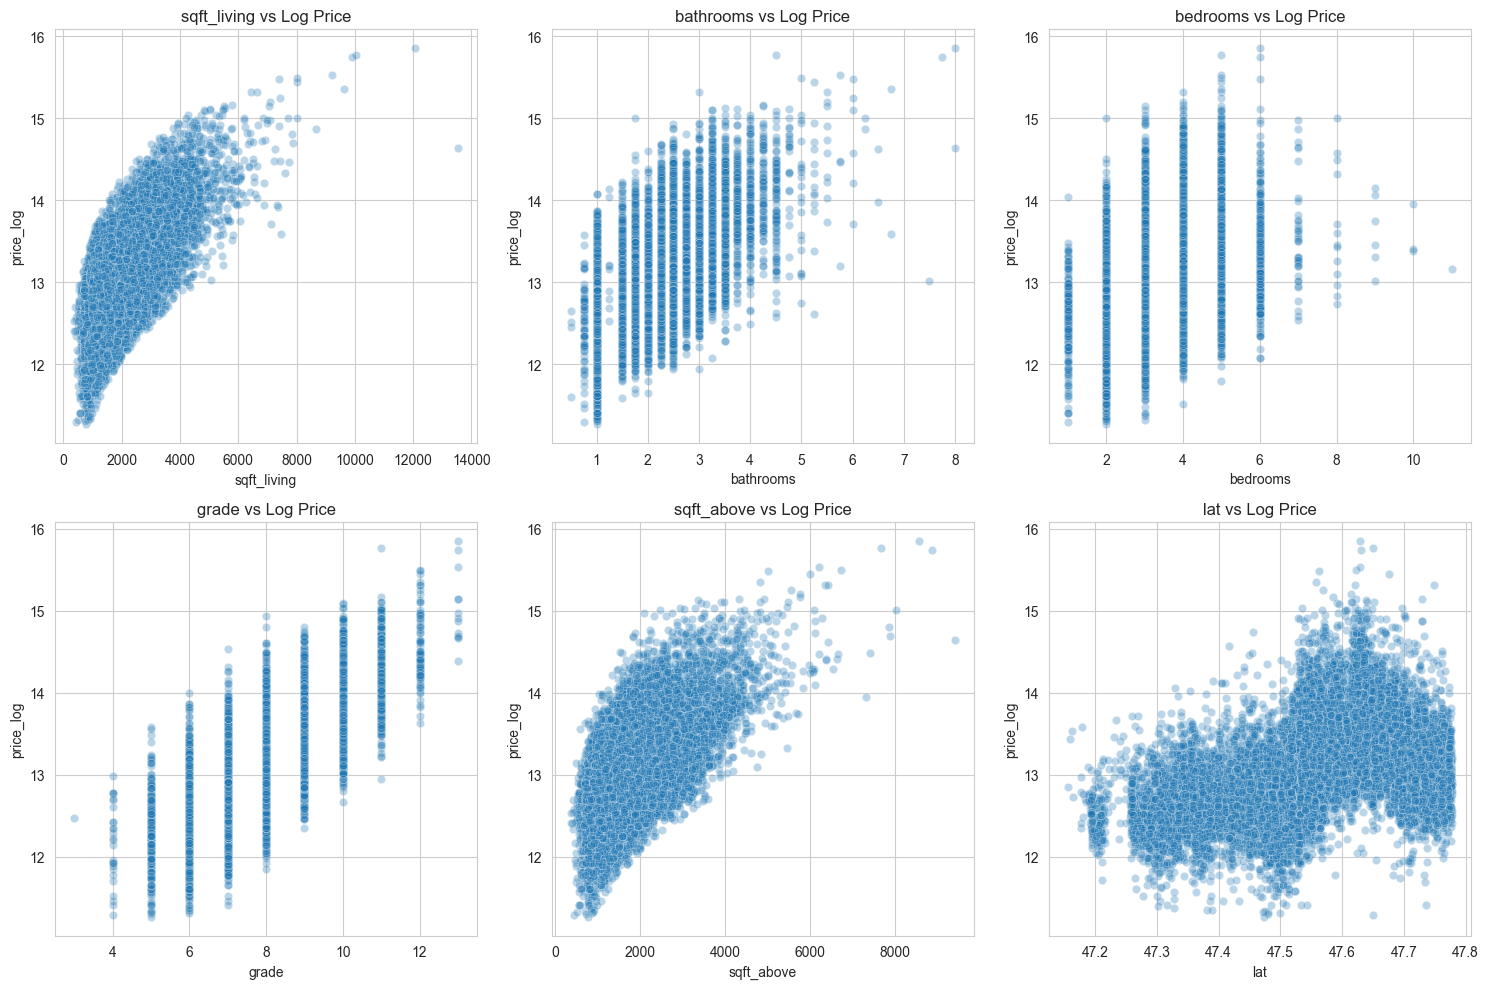

In [30]:
# ===============================================
# 8. Scatter plots of Important Features vs Log Price
# ===============================================

important_features = [
'sqft_living',
'bathrooms',
'bedrooms',
'grade',
'sqft_above',
'lat'
]

plt.figure(figsize=(15,10))
for i,col in enumerate(important_features,1):
    plt.subplot(2,3,i)
    sns.scatterplot(x=df[col], y=df['price_log'], alpha=0.3)
    plt.title(f"{col} vs Log Price")
plt.tight_layout()
plt.show()

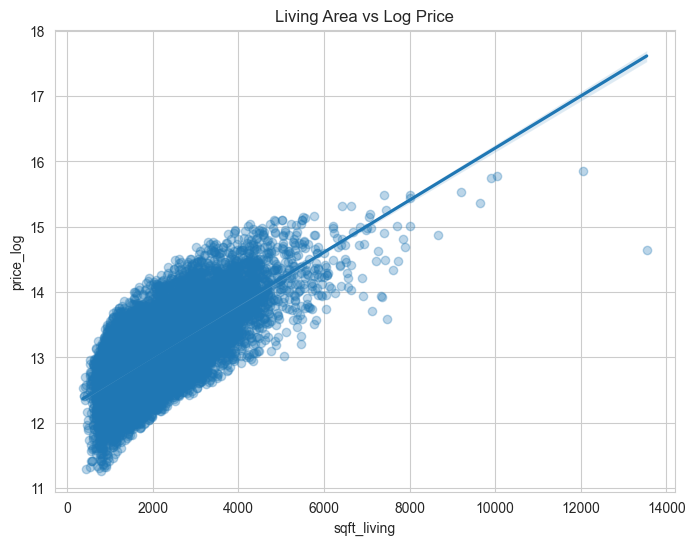

In [31]:
# ===============================================
# 9 Living Area vs Log Price
# ===============================================

plt.figure(figsize=(8,6))
sns.regplot(
    x="sqft_living",
    y="price_log",
    data=df,
    scatter_kws={"alpha":0.3}
)
plt.title("Living Area vs Log Price")
plt.show()

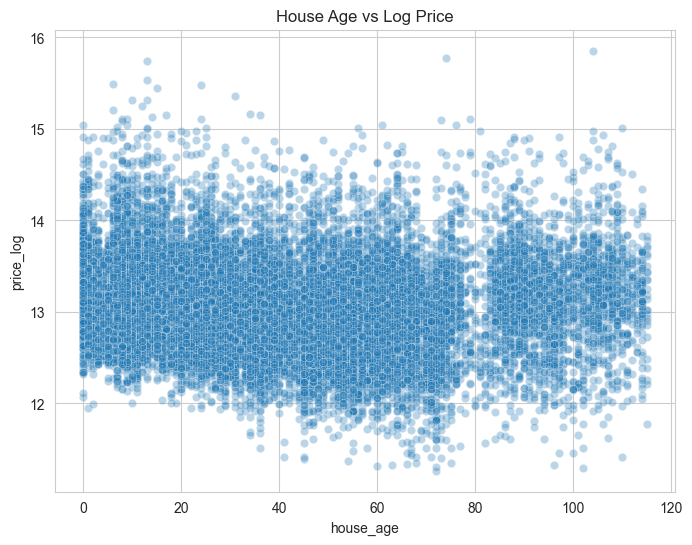

In [32]:
# ===============================================
# 10 House Age vs Log Price
# ===============================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df['house_age'],
    y=df['price_log'],
    alpha=0.3
)
plt.title("House Age vs Log Price")
plt.show()

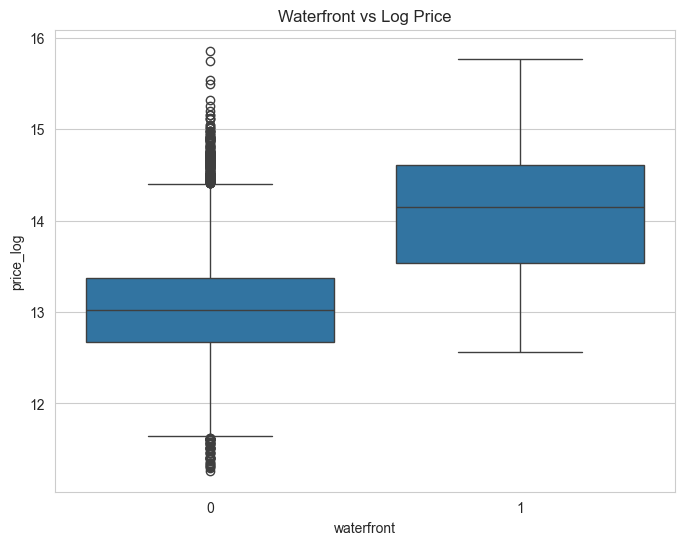

In [33]:
# ===============================================
# 11 Waterfront Impact
# ===============================================

plt.figure(figsize=(8,6))
sns.boxplot(x='waterfront', y='price_log', data=df)
plt.title("Waterfront vs Log Price")
plt.show()

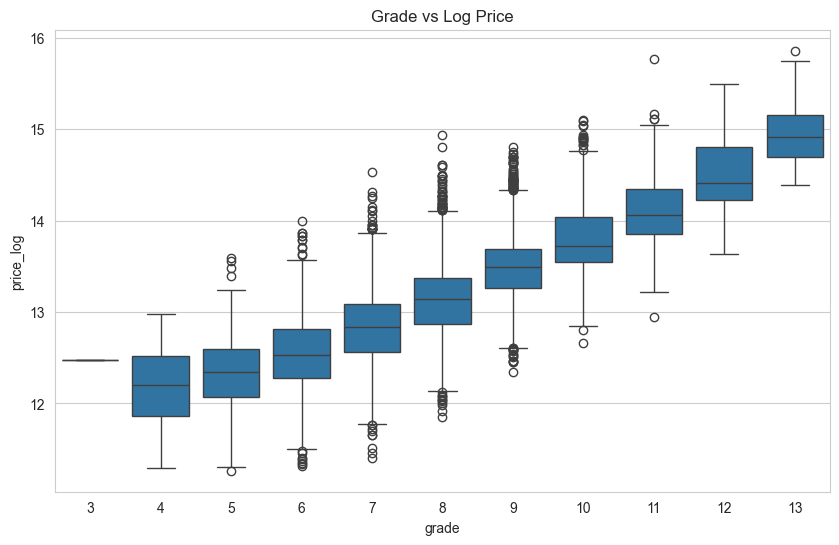

In [34]:
# ===============================================
# 12 Grade Impact
# ===============================================

plt.figure(figsize=(10,6))
sns.boxplot(x='grade', y='price_log', data=df)
plt.title("Grade vs Log Price")
plt.show()

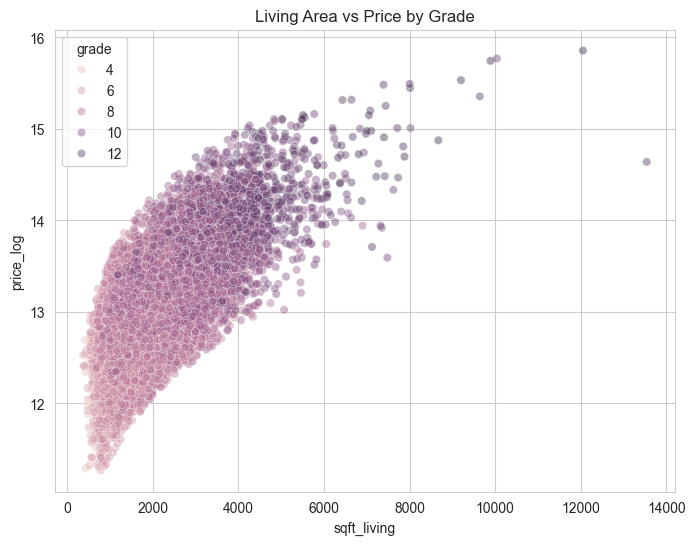

In [35]:
# ===============================================
# 13 Grade vs Living Area
# ===============================================

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=df["sqft_living"],
    y=df["price_log"],
    hue=df["grade"],
    alpha=0.4
)
plt.title("Living Area vs Price by Grade")
plt.show()

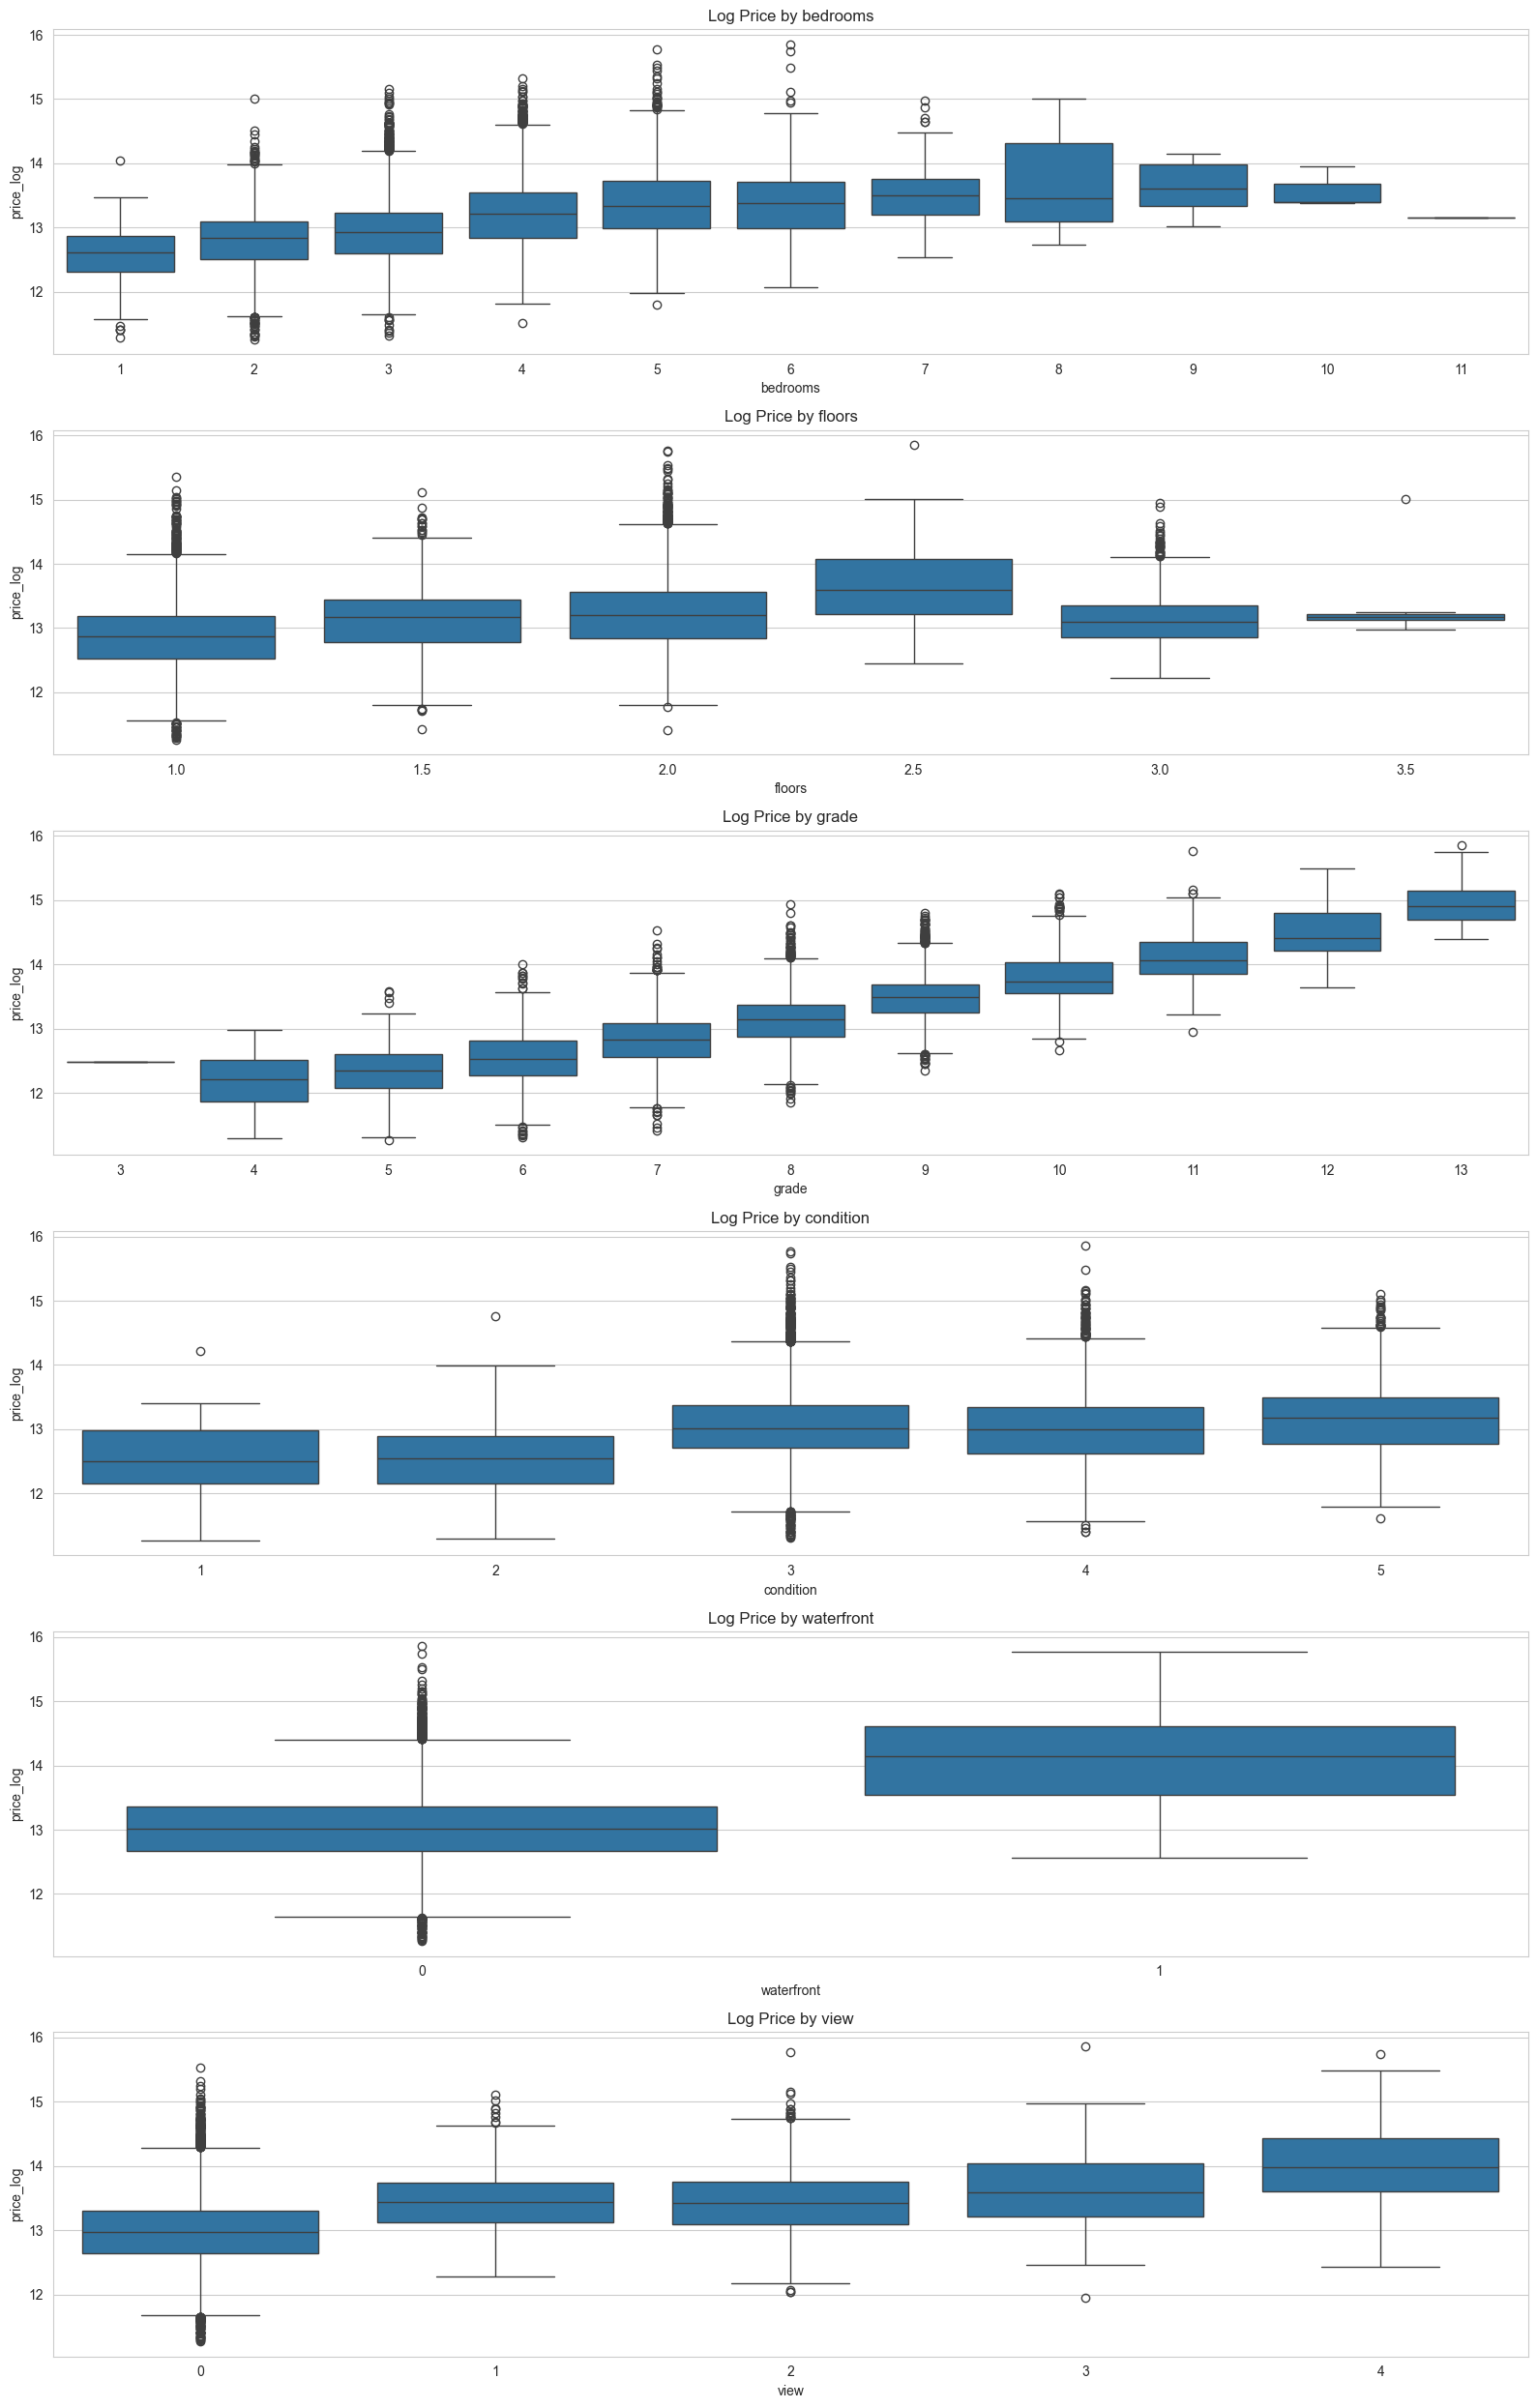

In [36]:
# ===============================================
# 14 Price by Categorical Features
# ===============================================

plt.figure(figsize=(16,25))
for i,col in enumerate(categorical_cols,1):
    plt.subplot(len(categorical_cols),1,i)
    sns.boxplot(x=df[col], y=df['price_log'])
    plt.title(f"Log Price by {col}")
plt.tight_layout()
plt.show()

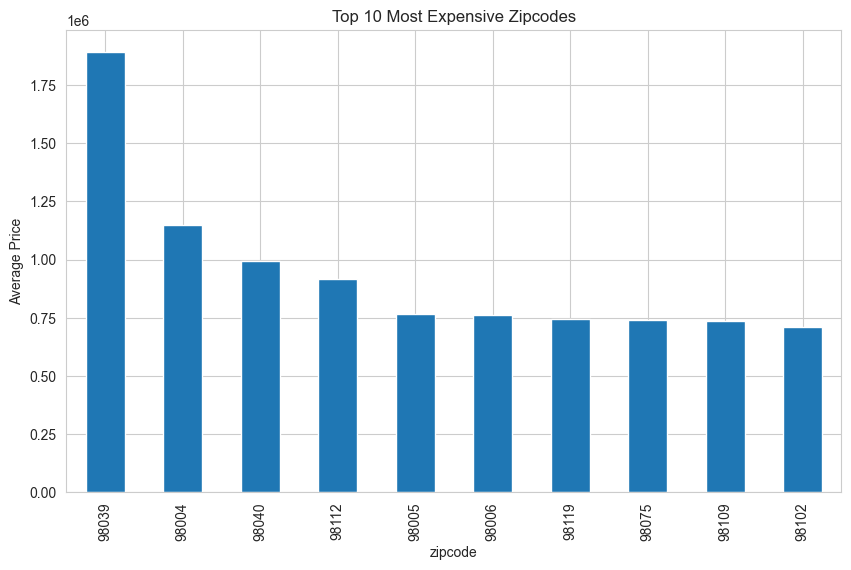

In [37]:
# ===============================================
# 15 Price by Zipcode
# ===============================================

top_zip = df.groupby('zipcode')['price'].median().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_zip.plot(kind='bar')
plt.title("Top 10 Most Expensive Zipcodes")
plt.ylabel("Average Price")
plt.show()

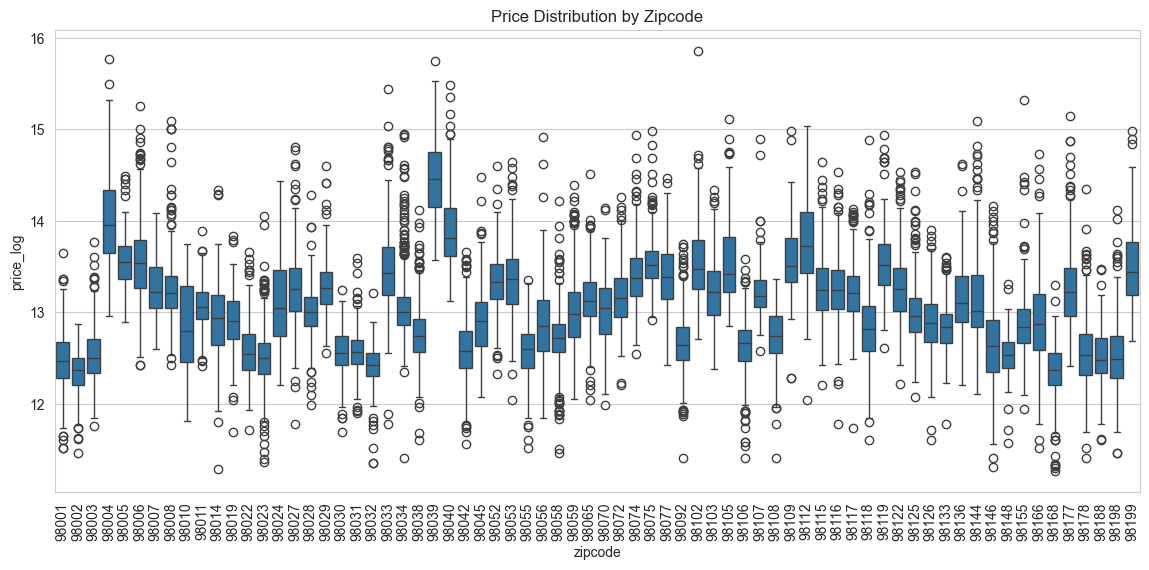

In [38]:
# ===============================================
# 16 Pairplot
# ===============================================

plt.figure(figsize=(14,6))
sns.boxplot(
    x=df["zipcode"],
    y=df["price_log"]
)
plt.xticks(rotation=90)
plt.title("Price Distribution by Zipcode")
plt.show()

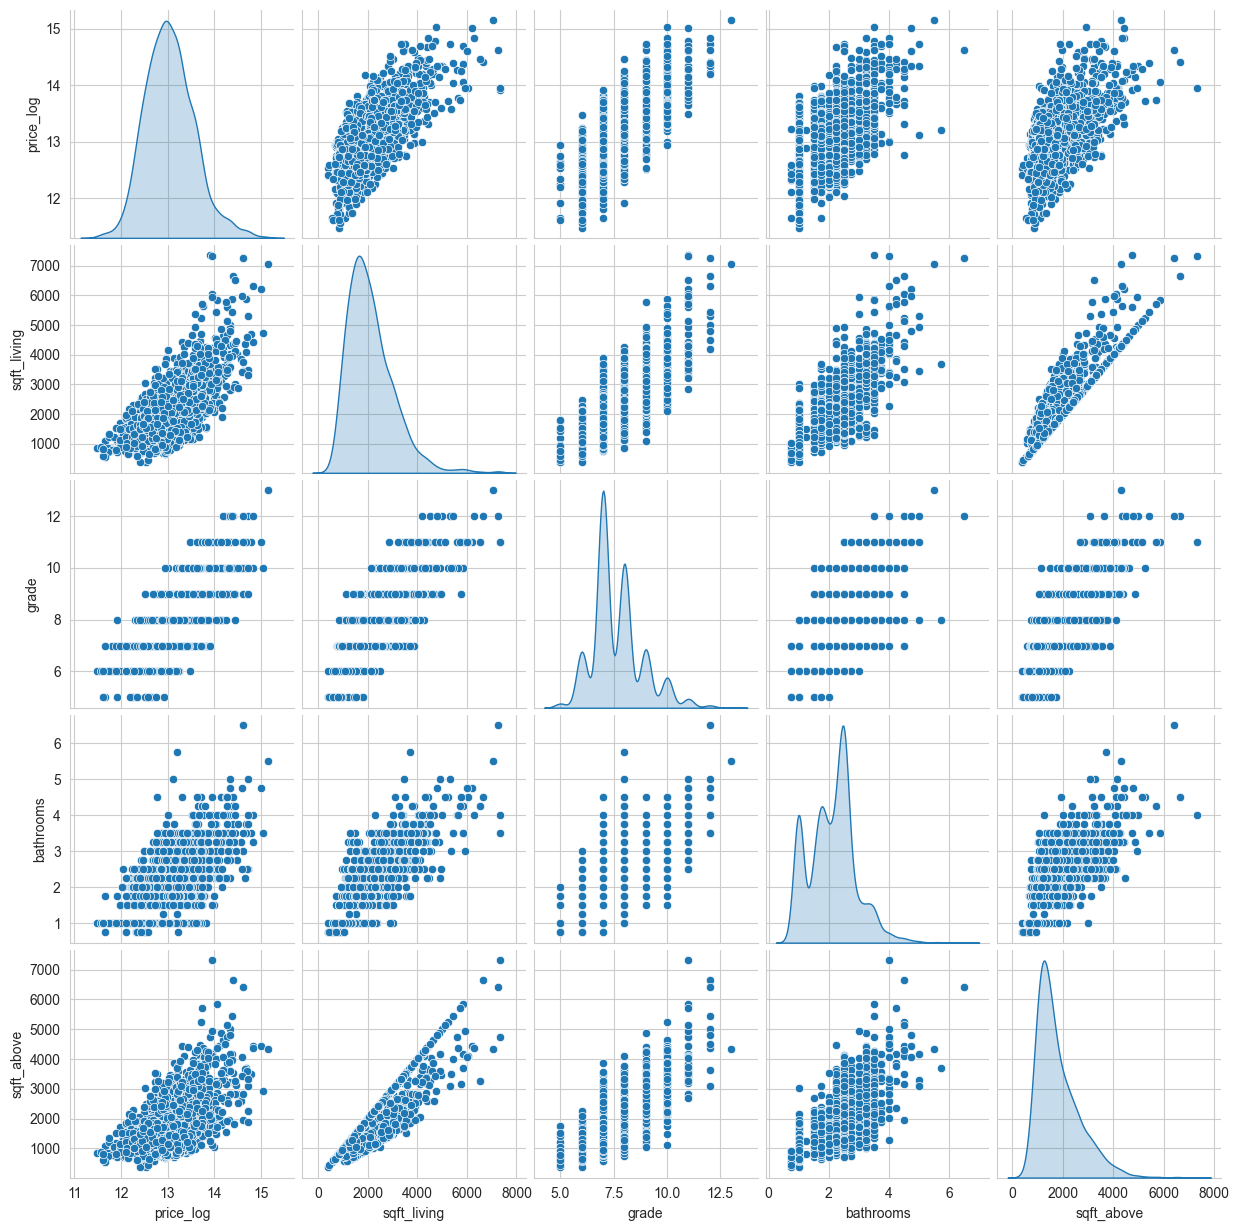

In [39]:
# ===============================================
# 17 Pairplot
# ===============================================

sample_df = df.sample(2000, random_state=42)
sns.pairplot(
    sample_df[[
        "price_log",
        "sqft_living",
        "grade",
        "bathrooms",
        "sqft_above"
    ]],   
    diag_kind="kde"
)
plt.show()

#### MULTIVARIANT ANALYSIS

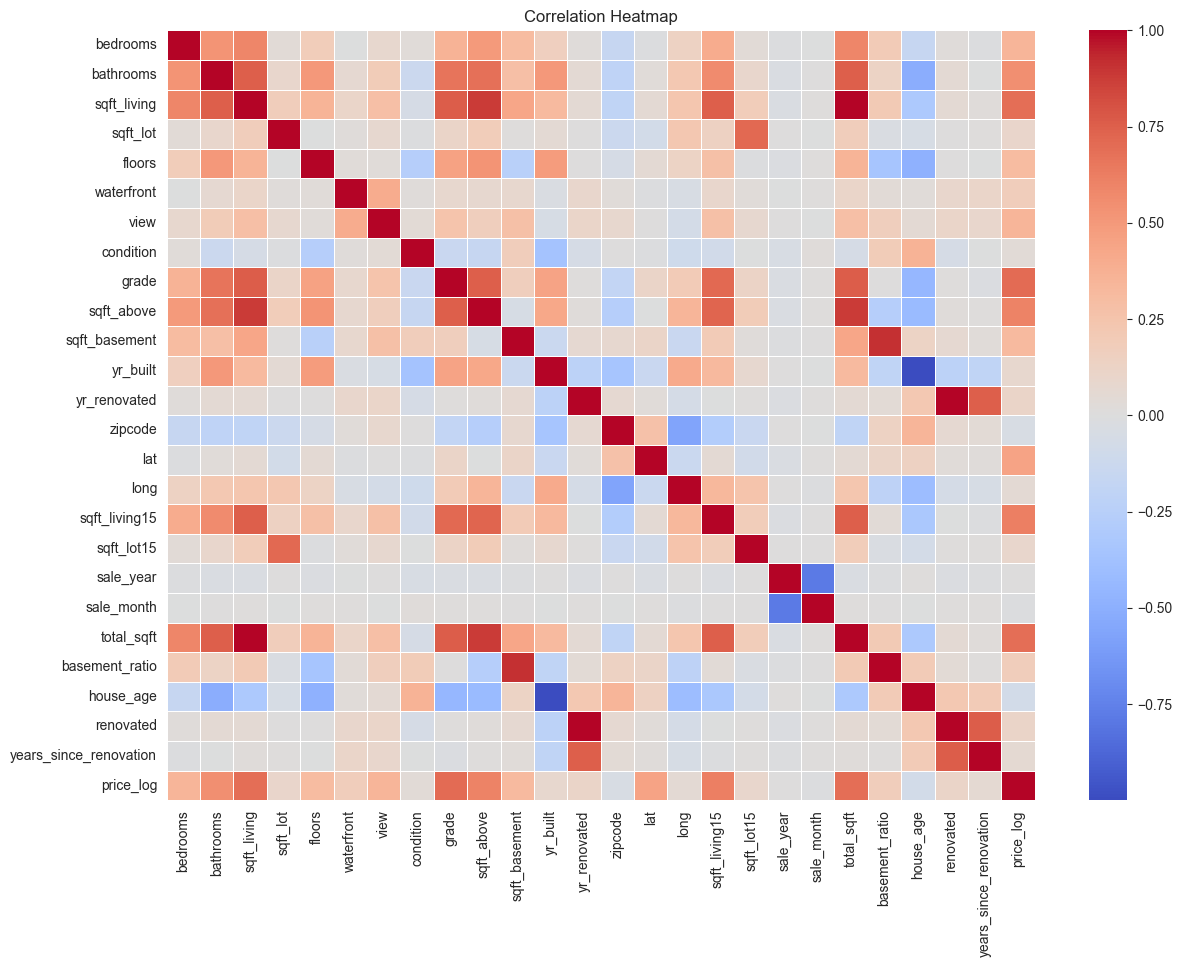

In [40]:
# 18 Correlation Analysis

corr_matrix = df.drop(columns=['price']).corr()
plt.figure(figsize=(14,10))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    linewidths=0.5,
    annot=False
)
plt.title("Correlation Heatmap")
plt.show()

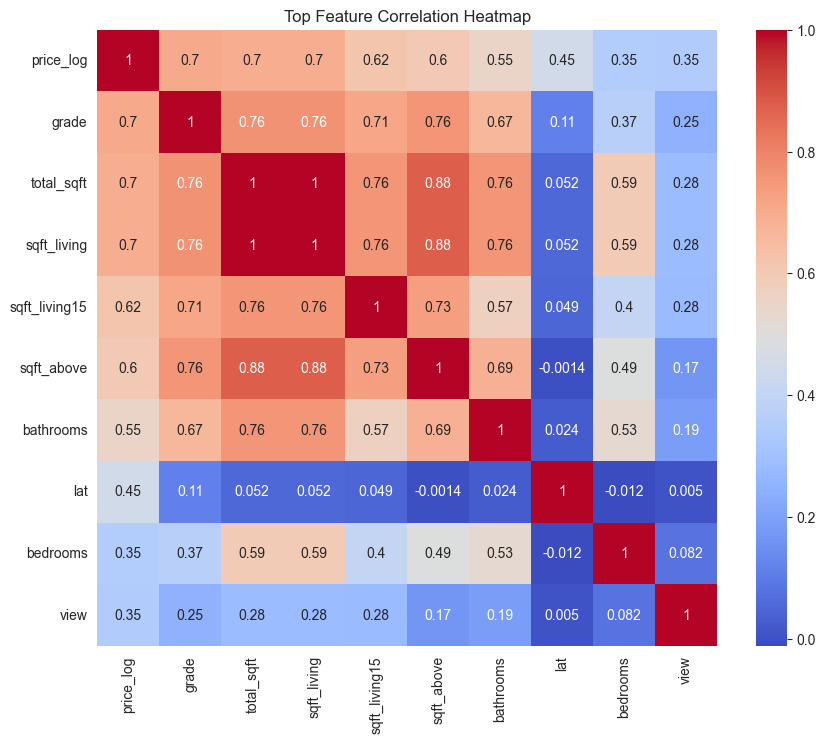

In [41]:
# ===============================================
# 19 Top Feature Correlation Heatmap
# ===============================================

top_features = corr_matrix['price_log'].abs().sort_values(ascending=False).head(10).index

plt.figure(figsize=(10,8))
sns.heatmap(
    df[top_features].corr(),
    annot=True,   
    cmap="coolwarm"
)
plt.title("Top Feature Correlation Heatmap")
plt.show()

price_log                 1.000000
grade                     0.703819
total_sqft                0.695203
sqft_living               0.695203
sqft_living15             0.619313
sqft_above                0.601643
bathrooms                 0.551349
lat                       0.448845
bedrooms                  0.350815
view                      0.346435
sqft_basement             0.316820
floors                    0.310902
waterfront                0.174722
basement_ratio            0.172010
yr_renovated              0.114219
renovated                 0.113842
sqft_lot                  0.100008
sqft_lot15                0.092260
yr_built                  0.080835
years_since_renovation    0.055393
long                      0.051049
condition                 0.038905
sale_year                 0.005154
sale_month               -0.013099
zipcode                  -0.039065
house_age                -0.080750
Name: price_log, dtype: float64


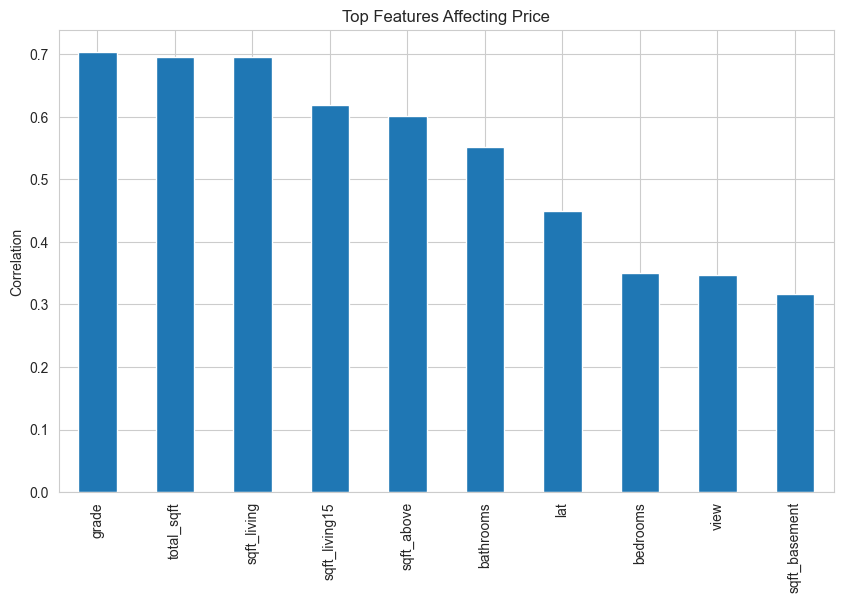

In [42]:
# ===============================================
# 20 Top Correlated Features
# ===============================================

corr = corr_matrix['price_log'].sort_values(ascending=False)
print(corr)

plt.figure(figsize=(10,6))
corr[1:11].plot(kind='bar')
plt.title("Top Features Affecting Price")
plt.ylabel("Correlation")
plt.show()

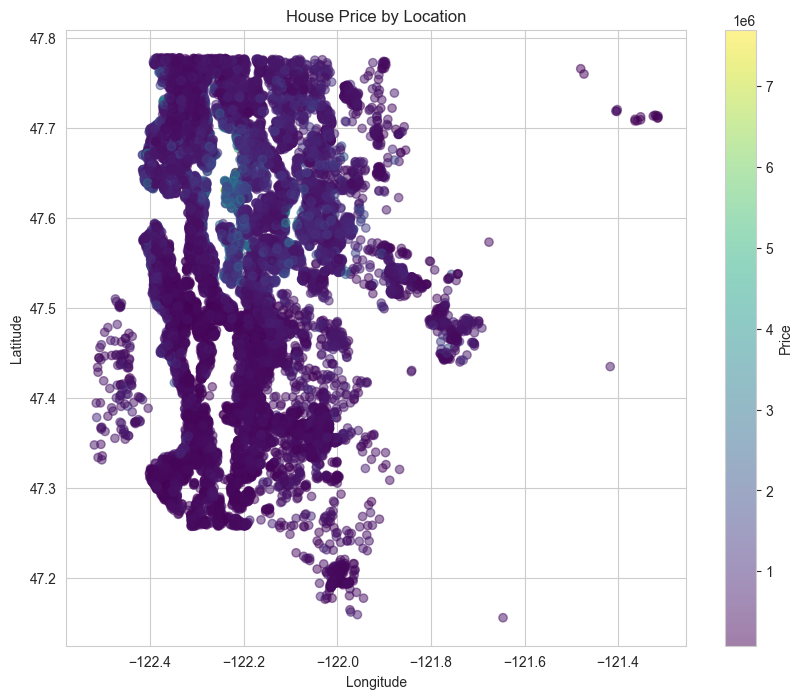

In [43]:
# ===============================================
# 21 Location Analysis
# ===============================================

plt.figure(figsize=(10,8))
plt.scatter(
    df['long'],
    df['lat'],
    c=df['price'],
    cmap='viridis',   
    alpha=0.5
)
plt.colorbar(label="Price")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("House Price by Location")
plt.show()

In [44]:
# ===============================================
# 22 Skewness Check
# ===============================================

skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print(skewness)

sqft_lot                  13.070445
waterfront                11.378371
sqft_lot15                 9.522799
years_since_renovation     7.969942
yr_renovated               4.563594
renovated                  4.563127
price                      4.025829
view                       3.398579
sqft_basement              1.575986
total_sqft                 1.473919
sqft_living                1.473919
sqft_above                 1.447757
sqft_living15              1.107062
condition                  1.035536
basement_ratio             0.913497
long                       0.884525
grade                      0.788745
sale_year                  0.757056
floors                     0.614249
bedrooms                   0.551731
bathrooms                  0.520181
house_age                  0.469502
price_log                  0.430475
zipcode                    0.405959
sale_month                 0.063356
yr_built                  -0.470059
lat                       -0.485277
dtype: float64
